# Target Volume Qualitative RECIST calculation  
Determining target volume selection based on diameter and performing RECIST with sum of diameters of up to 5 lesions.

In [1]:
%cd ../..

/home/bhkuser/bhklab/katy/recist-vs-reality


In [2]:
import pandas as pd
from pathlib import Path
from damply import dirs
from workflow.scripts.utils.metadata_ll import add_source_labels, add_sample_id_column
from workflow.scripts.lesion_locator_sim import get_recist_tum , get_indiv_percdiam_change
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import matplotlib.colors as mcolors

/home/bhkuser/bhklab/katy/recist-vs-reality/.pixi/envs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RECIST_PD_BOUNDARY = 20
RECIST_PR_BOUNDARY = -30

VRECIST_PD_BOUNDARY = 73
VRECIST_PR_BOUNDARY = -65

In [4]:
(-65+73)/2

4.0

In [5]:
def calc_RECIST(target_lesions: pd.DataFrame,
                t1_diam_col: str,
                t2_diam_col: str
                ) -> tuple[str, float]:
    
    sld_t1 = target_lesions[t1_diam_col].sum()
    sld_t2 = target_lesions[t2_diam_col].sum()

    delta_sld = sld_t2 - sld_t1

    delta_perc_diam = get_indiv_percdiam_change(sld_t1, sld_t2)

    response_cat = get_recist_tum(diam_change = delta_perc_diam)

    return response_cat, delta_sld, delta_perc_diam

In [6]:
def vRECIST_classifier(delta_vol_perc):

    if delta_vol_perc == -100:
        return 'CR'
    elif -100 < delta_vol_perc <= -65:
        return 'PR'
    elif -65 < delta_vol_perc < 73:
        return 'SD'
    elif 73 < delta_vol_perc:
        return 'PD'
    else:
        raise ValueError()


def calc_vRECIST(target_lesions: pd.DataFrame,
                t1_vol_col: str,
                t2_vol_col: str):
    sum_t1_vol = target_lesions[t1_vol_col].sum()
    sum_t2_vol = target_lesions[t2_vol_col].sum()

    delta_vol = sum_t2_vol - sum_t1_vol
    perc_delta_vol = delta_vol / sum_t1_vol * 100
    vRECIST = vRECIST_classifier(perc_delta_vol)

    return vRECIST, delta_vol, perc_delta_vol

In [7]:
dataset = "AI_for_Onc_2026" # Lesion Locator
model = "nnInt"

In [8]:
model_results_path = Path(f"data/results/{dataset}/{model}_ll_sim_plotting_info_pts_20260213.csv")
model_results_df = pd.read_csv(model_results_path)

In [9]:
name_mapping_df = pd.read_csv(dirs.RAWDATA / "MultiSite" / "CVPR_LesionLocator" / "images" / "naming.csv")

lbl_model_results_df = add_sample_id_column(model_results_df, "GT_t1_mask_path")
lbl_model_results_df = add_source_labels(lbl_model_results_df, name_mapping_df)


In [10]:
# add disease site labels
lung_datasets = ['LIDC-IDRI', 'LNDb', 'MSD Lung', 'NSCLC-Radiogenomics']
abdomen_datasets = ['KiTS', 'MSD Colon', 'MSD Hepatic Vessel', 'MSD Liver', 'MSD Pancreas']
datasets_list = lung_datasets + abdomen_datasets
lbl_model_results_df['disease_site'] = lbl_model_results_df['source_dataset'].apply(
    lambda x: 'lung' if x in lung_datasets else 'abdomen')

In [11]:
lbl_model_results_df['disease_site'].value_counts()

disease_site
lung       3165
abdomen    2321
Name: count, dtype: int64

In [12]:
# Set up human readable model title for plotting
match model:
    case "nnint" | "nnInt":
        model_title = "nnInteractive"
    case "ms2r":
        model_title = "MedSAM2-RECIST"
    case _:
        model_title = model

In [13]:
# Add average DICE calculations
lbl_model_results_df['avg_DICE'] = (lbl_model_results_df.t1_DICE + lbl_model_results_df.t2_DICE) / 2
lbl_model_results_df['avg_2D_DICE'] = (lbl_model_results_df.t1_2D_DICE + lbl_model_results_df.t2_2D_DICE) / 2

In [14]:
# Add distance to boundary calculations
lbl_model_results_df.loc[:,'dist_to_PD_RECIST'] = lbl_model_results_df.GT_perc_diam_change - RECIST_PD_BOUNDARY
lbl_model_results_df.loc[:,'dist_to_PR_RECIST'] = lbl_model_results_df.GT_perc_diam_change - RECIST_PR_BOUNDARY

lbl_model_results_df.loc[:,'dist_to_PD_vRECIST'] = lbl_model_results_df.GT_perc_vol_change - VRECIST_PD_BOUNDARY
lbl_model_results_df.loc[:,'dist_to_PR_vRECIST'] = lbl_model_results_df.GT_perc_vol_change - VRECIST_PR_BOUNDARY

In [15]:
# Filter down to samples with high 3D DICE
high_3d_dice = lbl_model_results_df[(lbl_model_results_df.t1_DICE > 0.80) & (lbl_model_results_df.t2_DICE > 0.80)].copy()

## Plot for AI4O

### Plotly scatter

In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def response_bar_and_scatter(
    hist_data:pd.Series,
    scatter_y_data:pd.Series,
    scatter_label:str,
    boundary_lines:str= 'RECIST', # or 'vRECIST'
    bin_min = -85,
    bin_max = 116,
    bin_size = 5,
    hist_color = 'grey',
    scatter_color = '#d62728'):
    
    # Calculate histogram data for bar chart
    _response_hist_counts, response_bin_edges = np.histogram(hist_data, bins=np.arange(bin_min, bin_max, bin_size))

    # Find the bin centers for the x data for the scatter plot
    bin_centers = np.arange((bin_min + (bin_size / 2)), bin_max, bin_size)
    # Find which bin each data point belongs to
    indices = np.digitize(hist_data, bins=response_bin_edges) - 1
    # Set these as the x values
    scatter_x_data = bin_centers[indices]

    if boundary_lines == 'RECIST':
        pd_boundary = RECIST_PD_BOUNDARY
        pr_boundary = RECIST_PR_BOUNDARY
        hist_label = 'Change in Diameter (%)'
    elif boundary_lines == 'vRECIST':
        pd_boundary = VRECIST_PD_BOUNDARY
        pr_boundary = VRECIST_PR_BOUNDARY
        hist_label = 'Change in Volume (%)'

    # Start setting up the figure
    # Add bar chart from histogram data
    trace_hist = go.Histogram(
        x=hist_data,
        xbins=go.histogram.XBins(end=bin_max, size=bin_size, start=bin_min),
        name=hist_label,
        opacity=0.6,
        marker=dict(color=hist_color,
                    line=dict(
                        color='black',
                        width=1))
    )

    trace_scatter = go.Scatter(
        x=scatter_x_data, 
        y=scatter_y_data,
        mode='markers',
        name='Response category flips',
        marker=dict(color=scatter_color, size=6),
        yaxis='y2'
    )

    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(trace_hist)
    fig.add_trace(trace_scatter, secondary_y=True)

    # Add PD and PR lines 
    fig.add_vline(x=pr_boundary, line_width=2, line_dash='dash', line_color='#2ca02c')
    fig.add_vline(x=pd_boundary, line_width=2, line_dash='dash', line_color='royalblue')


    fig.update_layout(
        xaxis=dict(
            title=hist_label,
            range=[-100,125],
            tickmode='linear',
            tick0=-100,
            dtick=25,
            ),
        yaxis = dict(
            title='Frequency', 
            title_font_color=hist_color,
            tickfont=dict(color=hist_color),
            range=[0,40],
            tickmode='linear',
            tick0=0,
            dtick=10,
            ),
        yaxis2 = dict(
            title=scatter_label, 
            title_font_color=scatter_color,
            tickfont=dict(color=scatter_color),
            range=[0.8,1],
            tickmode='linear',
            tick0=0.8,
            dtick=0.05
            ),
        barmode='overlay'
    )

    # fig.show()

    return fig

In [17]:
high3ddice_vRECISTflips = high_3d_dice[high_3d_dice['vol_RECIST_flip'] == True]

vRECIST_plot = response_bar_and_scatter(
    hist_data=high3ddice_vRECISTflips['GT_perc_vol_change'],
    scatter_y_data=high3ddice_vRECISTflips['avg_DICE'],
    scatter_label='Average 3D DSC',
    boundary_lines='vRECIST',
)

vRECIST_plot.update_layout(autosize=False, width=1000, height=600)

In [18]:
high3ddice_RECISTflips = high_3d_dice[high_3d_dice['RECIST_flip'] == True]

RECIST_plot = response_bar_and_scatter(
    hist_data=high3ddice_RECISTflips['GT_perc_diam_change'],
    scatter_y_data=high3ddice_RECISTflips['avg_DICE'],
    scatter_label='Average 3D DSC',
    boundary_lines='RECIST',
)

RECIST_plot.update_layout(autosize=False, width=1000, height=600)

### Distance to boundary plots

In [19]:
# r_pd_samples = high_3d_dice[high_3d_dice['GT_RECIST_cat'].isin(['PD','SD'])].copy()
# v_pd_samples = high_3d_dice[high_3d_dice.GT_vol_RECIST_cat.isin(['PD', 'SD'])].copy()

r_pd_samples = lbl_model_results_df[lbl_model_results_df.GT_RECIST_cat.isin(['PD','SD', 'PR'])].copy()
v_pd_samples = lbl_model_results_df[lbl_model_results_df.GT_vol_RECIST_cat.isin(['PD', 'SD', 'PR'])].copy()

bin_count=25

# r_hist, r_bin_edges = np.histogram(r_pd_samples.dist_to_PD_RECIST)
# v_pd_hist, v_pd_bin_edges = np.histogram(v_pd_samples.dist_to_PD_vRECIST)

In [20]:
import plotly.express as px

fig = px.histogram(r_pd_samples, x="dist_to_PD_RECIST", color="RECIST_flip", nbins=bin_count)
fig.show()

In [21]:
fig = px.histogram(v_pd_samples, x="dist_to_PD_vRECIST", color="vol_RECIST_flip", nbins=bin_count)
fig.show()

In [22]:
import plotly.graph_objects as go

histogram_data = r_pd_samples.copy()
histogram_data = histogram_data[(histogram_data.avg_DICE > 0.80) &
                                (histogram_data.RECIST_flip == 1)]

v_histogram_data = v_pd_samples[(v_pd_samples.avg_DICE > 0.80) &
                                (v_pd_samples.vol_RECIST_flip == 1)]

hist_figure = go.Figure()

fig = go.Figure()
fig.add_trace(go.Histogram(
    x = histogram_data['dist_to_PD_RECIST'],
    name='RECIST',
    xbins=dict(
        start=-30,
        end=80,
        size=5
    ),
    bingroup=1,
))
fig.add_trace(go.Histogram(
    x = v_histogram_data['dist_to_PD_vRECIST'],
    name='vRECIST',
    xbins=dict(
        start=-30,
        end=60,
        size=5
    ),
    bingroup=1
))

fig.update_layout(
    xaxis=dict(
            title='Distance from boundary',
            range=[-50,50],
            ),
        yaxis = dict(
            title='Frequency'
        ),

    title = 'Flipped samples',
    barmode='group',
)

fig.show()

In [23]:
histogra

NameError: name 'histogra' is not defined

In [ ]:
distance_scatter = go.Figure()

scatter_data = r_pd_samples.copy()
scatter_data = scatter_data[#(scatter_data.RECIST_flip == 1) & 
                            (scatter_data.dist_to_PD_RECIST > -30) &
                            (scatter_data.dist_to_PD_RECIST < 60) &
                            (scatter_data.avg_2D_DICE > 0.80)]

color_variable = 'RECIST_flip'

scatter_colors = scatter_data[color_variable].apply(lambda x: 'rgb(214, 39, 40)' if x is True else 'rgba(31, 119, 180, 0.5)')

distance_scatter.add_trace(go.Scatter(
    x = scatter_data.dist_to_PD_RECIST,
    y = scatter_data.avg_2D_DICE,
    mode='markers',
    marker=dict(color=scatter_colors),
))

distance_scatter.update_layout(autosize=True, width=600) #height=400)

In [ ]:
scatter_data

,GT_t1_mask_path,GT_t2_mask_path,GT_t1_max_ax_diam,GT_t2_max_ax_diam,GT_t1_vox_vol,GT_t2_vox_vol,GT_t1_cor_len,GT_t2_cor_len,GT_t1_sag_len,GT_t2_sag_len,...,sample_id,source_id,source_dataset,disease_site,dist_to_PD_RECIST,dist_to_PR_RECIST,dist_to_PD_vRECIST,dist_to_PR_vRECIST,avg_DICE,avg_2D_DICE
70,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,37.791000,42.747416,21084.710210,26855.002387,138.000000,156.000000,153.001794,162.000000,...,LesionLocator_0042,KiTS23_case_00045,KiTS,abdomen,-6.884666,43.115334,-45.632813,92.367187,0.903203,0.908563
118,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,39.356162,42.769424,19374.691772,30952.441406,47.756309,53.899356,41.496426,51.177540,...,LesionLocator_0063,KiTS23_case_00068,KiTS,abdomen,-11.327248,38.672752,-13.242922,124.757078,0.917031,0.920462
121,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,21.808213,25.555474,3433.749390,6623.519897,23.911478,29.737934,23.953263,29.598897,...,LesionLocator_0063,KiTS23_case_00068,KiTS,abdomen,-2.817200,47.182800,19.894680,157.894680,0.902907,0.919243
142,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,38.824352,49.843750,24548.583984,38724.578857,195.001894,255.005792,235.001571,265.001393,...,LesionLocator_0068,KiTS23_case_00073,KiTS,abdomen,8.382696,58.382696,-15.253309,122.746691,0.902391,0.969905
288,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,50.202321,49.133204,54973.901527,43956.631533,231.003863,222.016080,222.004020,207.001078,...,LesionLocator_0121,KiTS23_case_00131,KiTS,abdomen,-22.129617,27.870383,-93.040910,44.959090,0.872126,0.921494
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5393,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,65.495213,72.324951,91472.774822,131903.757983,69.309523,80.161571,73.756465,87.848080,...,LesionLocator_2336,MSD_pancreas_414,MSD Pancreas,abdomen,-9.572157,40.427843,-28.799982,109.200018,0.939936,0.929273
5411,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,15.585928,20.309972,1115.351334,3815.409993,22.514949,26.870712,15.354693,28.473775,...,LesionLocator_2525,NSCLC-Radiogenomics_R01-016,NSCLC-\nRadiogenomics,abdomen,10.309667,60.309667,169.081448,307.081448,0.924647,0.956750
5439,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,25.562835,30.093104,5034.713242,8512.838882,30.092328,39.197089,26.188996,32.239909,...,LesionLocator_2553,NSCLC-Radiogenomics_R01-048,NSCLC-\nRadiogenomics,abdomen,-2.277910,47.722090,-3.917105,134.082895,0.909561,0.900272
5452,data/procdata/MultiSite/CVPR_LesionLocator/ima...,data/procdata/MultiSite/CVPR_LesionLocator/ima...,29.450120,30.698254,4631.042480,7772.827148,67.500000,85.000000,67.572299,77.535432,...,LesionLocator_2566,NSCLC-Radiogenomics_R01-061,NSCLC-\nRadiogenomics,abdomen,-15.761871,34.238129,-5.158155,132.841845,0.885204,0.885680


### Matplotlib scatter

/tmp/ipykernel_4005813/2841034353.py:49: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax2.scatter(x_scatter_data, y_scatter_data, color=scatter_color_data, cmap='cool', alpha=1)


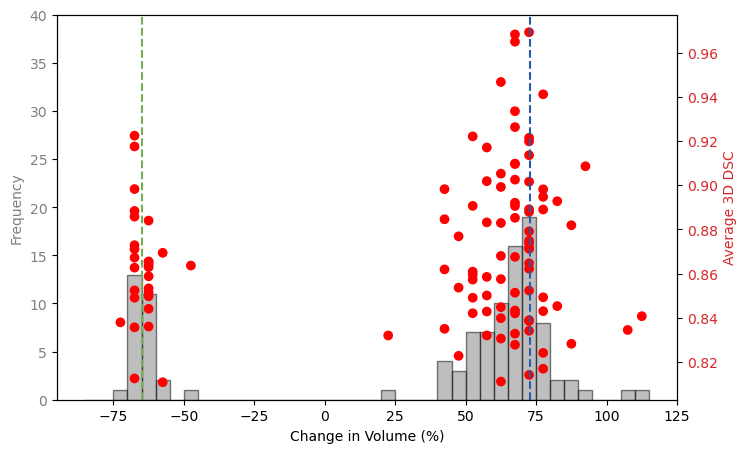

In [ ]:
# Scatter + histograms
high3ddice_vRECISTflips = high_3d_dice[high_3d_dice['vol_RECIST_flip'] == True]

x_hist_data = high3ddice_vRECISTflips['GT_perc_vol_change']
y_scatter_data = high3ddice_vRECISTflips['avg_DICE']
scatter_color_data = high3ddice_vRECISTflips['vol_RECIST_flip'].map({True: 'red', False: 'grey'})

bin_min = -85
bin_max = 116
bin_size = 5
bin_scatter_data = True
boundary_lines = 'vRECIST'

# Create the figure and the first axes (for the histogram)
fig, ax1 = plt.subplots(figsize=(8, 5))

# 3. Plot the histogram on the primary (left) y-axis
color1 = 'tab:gray'
ax1.set_ylabel('Frequency', color=color1)
ax1.set_xlabel('Change in Volume (%)')
# The histogram will use the 'ax2' y-axis scale
hist_counts, bin_edges, patches= ax1.hist(x_hist_data, 
        bins=np.arange(bin_min, bin_max, bin_size),
        color=color1, 
        alpha=0.5,
        edgecolor = 'black') 
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ybound(upper=40)

# 4. Instantiate a second axes that shares the same x-axis (for the histogram)
ax2 = ax1.twinx()  

# 5. Plot the scatter data on the secondary (right) y-axis
if bin_scatter_data:
    bin_centers = np.arange((bin_min + (bin_size / 2)), bin_max, bin_size)
    # Find which bin each data point belongs to
    indices = np.digitize(x_hist_data, bins=bin_edges) - 1
    # If a value is larger than the rightmost edge, digitize can return an out-of-bounds index,
    # this handles edge cases if any data falls outside the specified range.
    # indices = np.clip(indices, 0, len(bin_centers) - 1)
    # Map data points to their corresponding bin centers for the scatter plot
    x_scatter_data = bin_centers[indices]

else:
    x_scatter_data = x_hist_data

color2 = 'tab:red'
ax2.set_ylabel('Average 3D DSC', color=color2)
ax2.scatter(x_scatter_data, y_scatter_data, color=scatter_color_data, cmap='cool', alpha=1)
ax2.tick_params(axis='y', labelcolor=color2)
# ax2.set_ylim(0.73, 1)

# Plot vertical lines for RECIST thresholds
if boundary_lines == 'RECIST':
    pd_boundary = RECIST_PD_BOUNDARY
    pr_boundary = RECIST_PR_BOUNDARY
elif boundary_lines == 'vRECIST':
    pd_boundary = VRECIST_PD_BOUNDARY
    pr_boundary = VRECIST_PR_BOUNDARY

ax2.axvline(x = pr_boundary, linestyle='--', color="#75AF55", label='PR Threshold')
ax2.axvline(x = pd_boundary, linestyle='--', color="#255CAA", label='PD Threshold')

# 6. Add title and ensure layout is tight
# plt.suptitle(suptitle)
# plt.title("Tumours with DSC > 0.8 Misclassified by vRECIST")
# fig.legend(loc='lower right', ncols = 2)
# fig.tight_layout() # Ensures labels don't get clipped

# 7. Display the plot
plt.show()

In [ ]:
# Scatter + histograms
high3ddice_RECISTflips = high_3d_dice[high_3d_dice['RECIST_flip'] == True]

x_hist_data = high3ddice_RECISTflips['GT_perc_diam_change']
y_scatter_data = high3ddice_RECISTflips['avg_DICE']
scatter_color_data = high3ddice_RECISTflips['RECIST_flip'].map({True: 'red', False: 'grey'})

bin_min = -85
bin_max = 115
bin_size = 5
bin_scatter_data = True
boundary_lines = 'RECIST'


hist = np.histogram(x_hist_data, bins=np.arange(bin_min, bin_max, bin_size))

# Create the figure and the first axes (for the histogram)
fig, ax1 = plt.subplots(figsize=(16, 10))

# 3. Plot the histogram on the primary (left) y-axis
color1 = 'tab:gray'
ax1.set_ylabel('Frequency', color=color1)
ax1.set_xlabel('Change in Diameter (%)')
# The histogram will use the 'ax2' y-axis scale
hist_counts, bin_edges, patches= ax1.hist(x_hist_data, 
        bins=np.arange(bin_min, bin_max, bin_size),
        color=color1, 
        alpha=0.5,
        edgecolor = 'black') 
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ybound(upper=40)

# 4. Instantiate a second axes that shares the same x-axis (for the histogram)
ax2 = ax1.twinx()  

# 5. Plot the scatter data on the secondary (right) y-axis
if bin_scatter_data:
    bin_centers = np.arange((bin_min + (bin_size / 2)), bin_max, bin_size)
    # Find which bin each data point belongs to
    indices = np.digitize(x_hist_data, bins=bin_edges) - 1
    # If a value is larger than the rightmost edge, digitize can return an out-of-bounds index,
    # this handles edge cases if any data falls outside the specified range.
    # indices = np.clip(indices, 0, len(bin_centers) - 1)
    # Map data points to their corresponding bin centers for the scatter plot
    x_scatter_data = bin_centers[indices]

else:
    x_scatter_data = x_hist_data

color2 = 'tab:red'
ax2.set_ylabel('Average 3D DSC', color=color2)
ax2.scatter(x_scatter_data, y_scatter_data, color='red', cmap='cool', alpha=0.7, s=20)
ax2.tick_params(axis='y', labelcolor=color2)
# ax2.set_ylim(0.73, 1)

# Plot vertical lines for RECIST thresholds
if boundary_lines == 'RECIST':
    pd_boundary = RECIST_PD_BOUNDARY
    pr_boundary = RECIST_PR_BOUNDARY
elif boundary_lines == 'vRECIST':
    pd_boundary = VRECIST_PD_BOUNDARY
    pr_boundary = VRECIST_PR_BOUNDARY

ax2.axvline(x = pr_boundary, linestyle='--', color="#75AF55", linewidth=2, label='PR Threshold')
ax2.axvline(x = pd_boundary, linestyle='--', color="#005EE2", linewidth=2, label='PD Threshold')

ax2.set_xbound(-100, 125)
# 6. Add title and ensure layout is tight
# plt.suptitle(suptitle)
# plt.title("Tumours with DSC > 0.8 Misclassified by RECIST")
# fig.legend(loc='lower right', ncols = 2)
# fig.tight_layout() # Ensures labels don't get clipped

# 7. Display the plot
plt.show()

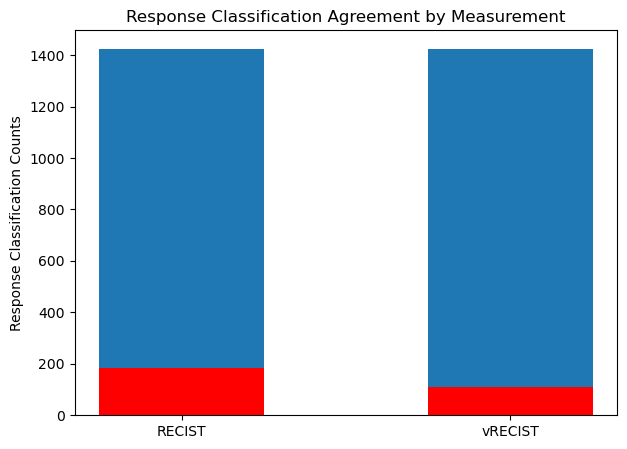

In [ ]:
stack_bar_fig, stack_bar_ax = plt.subplots(figsize = (7,5))

len(high_3d_dice[high_3d_dice.RECIST_flip == True])

categories = ('RECIST', 'vRECIST')
correct_responses = (len(high_3d_dice[high_3d_dice.RECIST_flip == False]), len(high_3d_dice[high_3d_dice.vol_RECIST_flip == False]))
incorrect_responses = (len(high_3d_dice[high_3d_dice.RECIST_flip == True]), len(high_3d_dice[high_3d_dice.vol_RECIST_flip == True]))

ind = np.arange(len(categories))
width = 0.5


incorrect_bar = stack_bar_ax.bar(ind, incorrect_responses, width, label='Incorrect Response Classifications', color='red')
correct_bar = stack_bar_ax.bar(ind, correct_responses, width, bottom=incorrect_responses, label='Correct Response Classifications')

stack_bar_ax.set_ylabel('Response Classification Counts')
stack_bar_ax.set_xticks(ind, categories)
# stack_bar_fig.legend(loc='lower center', ncols=2)

stack_bar_ax.set_title('Response Classification Agreement by Measurement')

plt.show()

In [ ]:
stack_bar_fig, stack_bar_ax = plt.subplots(figsize = (7,5))



categories = ('RECIST', 'vRECIST')
correct_responses = (len(high_3d_dice[high_3d_dice.RECIST_flip == False]) / 1425 * 100, len(high_3d_dice[high_3d_dice.vol_RECIST_flip == False])/ 1425 * 100)
incorrect_responses = (len(high_3d_dice[high_3d_dice.RECIST_flip == True])/ 1425 * 100, len(high_3d_dice[high_3d_dice.vol_RECIST_flip == True])/ 1425 * 100)

ind = np.arange(len(categories))
width = 0.5


incorrect_bar = stack_bar_ax.bar(ind, incorrect_responses, width, label='Incorrect Response Classifications', color='red')
correct_bar = stack_bar_ax.bar(ind, correct_responses, width, bottom=incorrect_responses, label='Correct Response Classifications')

stack_bar_ax.set_ylabel('Response Classification Percentage')
stack_bar_ax.set_xticks(ind, categories)
stack_bar_fig.legend(loc='lower center', ncols=2)

stack_bar_ax.set_title('Response Classification Agreement by Measurement')

plt.show()

In [ ]:
high3ddice_RECISTflips['t1_RECIST_sphere'] = high3ddice_RECISTflips['GT_t1_max_ax_diam'].apply(lambda x: 4/3 * np.pi * (x/2)**2)
high3ddice_RECISTflips['t2_RECIST_sphere'] = high3ddice_RECISTflips['GT_t2_max_ax_diam'].apply(lambda x: 4/3 * np.pi * (x/2)**2)

high3ddice_RECISTflips['t1_RECIST_sphere'] = high3ddice_RECISTflips['GT_t1_max_ax_diam'].apply(lambda x: 4/3 * np.pi * (x/2)**2)
high3ddice_RECISTflips['t2_RECIST_sphere'] = high3ddice_RECISTflips['GT_t2_max_ax_diam'].apply(lambda x: 4/3 * np.pi * (x/2)**2)
high3ddice_RECISTflips['GT_perc_sphere_vol_change'] = (high3ddice_RECISTflips['t2_RECIST_sphere'] - high3ddice_RECISTflips['t1_RECIST_sphere']) / high3ddice_RECISTflips['t1_RECIST_sphere'] * 100
high3ddice_RECISTflips['GT_sphere_vRECIST_cat'] = high3ddice_RECISTflips['GT_perc_sphere_vol_change'].apply(vRECIST_classifier)

In [ ]:
plt.scatter(high3ddice_RECISTflips['GT_perc_diam_change'], high3ddice_RECISTflips['GT_perc_sphere_vol_change'])
plt.axvline(x = 20, linestyle='--', color="#066F00", label='RECIST PD Threshold')
plt.axvline(x = -30, linestyle='--', color="#FF950A", label='RECIST PR Threshold')

plt.axhline(y = 73, linestyle='--', color='red', label='vRECIST PD Threshold')
plt.axhline(y=-65, linestyle='--', color='purple', label='vRECIST PD Threshold')

plt.ylabel('Change in Spherical RECIST estimate Volume (%)')
plt.xlabel('Change in Diameter (%)')

plt.legend(loc='lower right')

# Metadata plots about flipped samples

In [ ]:
np.arange(bin_min, bin_max, bin_size)

In [ ]:
high3ddice_RECISTflips['perc_diam_binned']= pd.cut(high3ddice_RECISTflips['GT_perc_diam_change'], bins=np.arange(-45, 35, 10))

In [ ]:
label_list = [5,10,15,20,25,30,35,40]
label_list.reverse()
size_list = dict(zip(label_list, range(240,20,-30)))
size_list

label_list = [5,10,15,20,25,30,35,40]
abdomen_data['diam_change_cat'] = pd.cut(abdomen_data['GT_perc_diam_change'].abs(), bins=[0,5,10,15,20,25,30,35,40], labels=label_list)
# size_list = dict(zip(label_list, range(20,200,20)))

lung_data['diam_change_cat'] = pd.cut(lung_data['GT_perc_diam_change'].abs(), bins=[0,5,10,15,20,25,30,35,40], labels=label_list)

In [ ]:
import seaborn as sns

vir_cat = mpl.colormaps['viridis'].resampled(6).colors[1:]

fig, ax = plt.subplots(1,2, figsize=(22,8))

abdomen_ax = ax[0]
abdomen_data = high3ddice_RECISTflips#[high3ddice_RECISTflips['disease_site'] == 'abdomen']
sns.scatterplot(x=abdomen_data['GT_t1_max_ax_diam'],
                y=abdomen_data['PRED_t1_max_ax_diam'],
                hue= abdomen_data['GT_RECIST_cat'],
                size=abdomen_data['GT_perc_diam_change'],
                style=abdomen_data['disease_site'],
                # hue_order = datasets_list,
                # palette=list(mpl.colormaps['rainbow'].resampled(5)(range(5))),
                sizes=(20,150),
                ax=abdomen_ax)
abdomen_ax.set_xbound(0,90)
abdomen_ax.set_ybound(0,90)

# lung_ax = ax[1]
# lung_data = high3ddice_RECISTflips#[high3ddice_RECISTflips['disease_site'] == 'lung']
# sns.scatterplot(x=lung_data['GT_t1_max_ax_diam'],
#                 y=lung_data['PRED_t1_max_ax_diam'],
#                 hue= lung_data['GT_RECIST_cat'],
#                 size=lung_data['GT_perc_diam_change'],
#                 style=lung_data['disease_site'],
#                 # hue_order = lung_datasets,
#                 # palette = '', #list(mpl.colormaps['viridis'].resampled(5)(range(1,5))),
#                 sizes=(20,150),
#                 ax=lung_ax)
# lung_ax.set_xbound(0,42)
# lung_ax.set_ybound(0,42)

vrecist_ax = ax[1]
vrecist_data = high3ddice_vRECISTflips#[high3ddice_RECISTflips['disease_site'] == 'abdomen']
sns.scatterplot(x=vrecist_data['GT_t1_vox_vol'],
                y=vrecist_data['PRED_t1_vox_vol'],
                hue= vrecist_data['GT_vol_RECIST_cat'],
                size=vrecist_data['GT_perc_vol_change'],
                style=vrecist_data['disease_site'],
                # hue_order = datasets_list,
                # palette=list(mpl.colormaps['rainbow'].resampled(5)(range(5))),
                sizes=(20,150),
                ax=vrecist_ax)
# vrecist_ax.set_xbound(0,10000)
# vrecist_ax.set_ybound(0,10000)

In [ ]:
mpl.colormaps['viridis'].resampled(6).colors[1:]

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(30,5))

diam_ax = ax[0]
diam_ax.scatter(
    high3ddice_RECISTflips['source_dataset'],
    high3ddice_RECISTflips['GT_t1_max_ax_diam'],   
)
diam_ax.set_ylabel('T1 Diameter')

vol_ax = ax[1]
vol_ax.scatter(
    high3ddice_RECISTflips['source_dataset'],
    high3ddice_RECISTflips['GT_t1_vox_vol'],
)
vol_ax.set_ylabel('T1 Volume')


vol_thresh_ax = ax[2]
limvol_highdice_flips = high3ddice_RECISTflips[high3ddice_RECISTflips['GT_t1_vox_vol'] < 20000]
vol_thresh_ax.scatter(
    limvol_highdice_flips['source_dataset'],
    limvol_highdice_flips['GT_t1_vox_vol']
)
vol_thresh_ax.set_ylabel('T1 Volume')

# Finding samples for visualization

### RECIST boundary samples

In [ ]:
pr_boundary_samples = high_3d_dice[(high_3d_dice['GT_perc_diam_change'] > RECIST_PR_BOUNDARY - 5) & (high_3d_dice['GT_perc_diam_change'] < RECIST_PR_BOUNDARY + 10)]
pd_boundary_samples = high_3d_dice[(high_3d_dice['GT_perc_diam_change'] > RECIST_PD_BOUNDARY - 5) & (high_3d_dice['GT_perc_diam_change'] < RECIST_PD_BOUNDARY + 10)]

In [ ]:
boundary_samples = pr_boundary_samples.loc[:,['sample_id', 'source_id', 'RECIST_flip', 'GT_t1_max_ax_diam', 'avg_2D_DICE', 'GT_perc_diam_change', 'PRED_perc_diam_change', 'GT_RECIST_cat', 'PRED_RECIST_cat', 'GT_t1_vox_vol', 'avg_DICE', 'GT_perc_vol_change', 'PRED_perc_diam_change', 'GT_vol_RECIST_cat', 'PRED_vol_RECIST_cat', 'source_dataset']]

In [ ]:
boundary_samples.sort_values(by=['RECIST_flip', 'source_dataset', 'avg_2D_DICE'], ascending=False)

In [ ]:
pr_boundary_sample_list = [5076,4168,1598,3609,1384,1532,1122,3816,1359, # lung samples 
    
    3029, 1598, 5171, 4966, 1083, 1043, 1241]

pd_boundary_sample_list = [5439,5099,3875,3425,5405,3934,2250, # lung samples
                           5388,4915,4548,4255,352,5368,4999,4422,4310,813] # abdomen samples

In [ ]:
boundary_samples.loc[pd_boundary_sample_list,:]

# Calculations for abstract methods/results

In [ ]:
high_2d_dice = lbl_model_results_df[(lbl_model_results_df['t1_2D_DICE'] > 0.80) & (lbl_model_results_df['t1_2D_DICE'] > 0.80)]
high_3d_dice = lbl_model_results_df[(lbl_model_results_df['t1_DICE'] > 0.80) & (lbl_model_results_df['t2_DICE'] > 0.80)]

In [ ]:
high_3d_dice['source_dataset'].value_counts()

source_dataset
LIDC-IDRI                771
KiTS                     325
MSD Hepatic\nVessel       83
LNDb                      78
MSD Liver                 65
MSD Pancreas              49
NSCLC-\nRadiogenomics     31
MSD Lung                  15
MSD Colon                  8
Name: count, dtype: int64

In [ ]:
high3ddice_responses = high_3d_dice[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]
high2ddice_responses = high_2d_dice[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]

In [ ]:
agreement_counts = pd.DataFrame(high3ddice_responses.value_counts())
agreement_counts['percent'] = agreement_counts.apply(lambda x: x/len(high3ddice_responses))
agreement_counts

count   percent
RECIST_flip ell_vol_RECIST_flip vol_RECIST_flip                 
False       False               False             1087  0.762807
True        False               False              106  0.074386
False       True                False               73  0.051228
            False               True                67  0.047018
True        True                False               49  0.034386
            False               True                20  0.014035
False       True                True                14  0.009825
True        True                True                 9  0.006316

In [ ]:
high3ddice_responses.apply(pd.Series.value_counts)

,RECIST_flip,ell_vol_RECIST_flip,vol_RECIST_flip
False,1241,1280,1315
True,184,145,110


In [ ]:
high2ddice_responses.apply(pd.Series.value_counts)

,RECIST_flip,ell_vol_RECIST_flip,vol_RECIST_flip
False,3341,3456,3508
True,812,697,645


In [ ]:
pd_2d_boundary = RECIST_PD_BOUNDARY
pr_2d_boundary = RECIST_PR_BOUNDARY
incl_range = 5

at_2d_boundaries = high_2d_dice[(high_2d_dice['GT_perc_diam_change'] > pr_2d_boundary - incl_range) & (high_2d_dice['GT_perc_diam_change'] < pr_2d_boundary + incl_range) |
                          (high_2d_dice['GT_perc_diam_change'] > pd_2d_boundary - incl_range) & (high_2d_dice['GT_perc_diam_change'] < pd_2d_boundary + incl_range)]

boundary_2d_responses = at_2d_boundaries[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]
boundary_2d_responses.apply(pd.Series.value_counts)

,RECIST_flip,ell_vol_RECIST_flip,vol_RECIST_flip
False,433,517,567
True,303,219,169


In [ ]:
pd_3d_boundary = VRECIST_PD_BOUNDARY
pr_3d_boundary = VRECIST_PR_BOUNDARY
incl_range = 10

at_3d_boundaries = high_3d_dice[(high_3d_dice['GT_perc_vol_change'] > pr_3d_boundary - incl_range) & (high_3d_dice['GT_perc_vol_change'] < pr_3d_boundary + incl_range) |
                          (high_3d_dice['GT_perc_vol_change'] > pd_3d_boundary - incl_range) & (high_3d_dice['GT_perc_vol_change'] < pd_3d_boundary + incl_range)]

boundary_3d_responses = at_3d_boundaries[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]
boundary_3d_responses.apply(pd.Series.value_counts)

,RECIST_flip,ell_vol_RECIST_flip,vol_RECIST_flip
False,189,199,169
True,55,45,75


In [ ]:
# Hexbin with histograms (hopefully)
hex_fig, flip_ax = plt.figure()


# Middle plot coloured by RECIST flip
flip_hb = flip_ax.hexbin(x=lbl_model_results_df['x_val'],
                        y=target_recist_results[y_val],
                        C=target_recist_results[recist_type],
                        reduce_C_function=np.mean,
                        gridsize=count_gridsize,
                        cmap='cool',
                        mincnt=1)
flip_ax.set_title("RECIST Flip Rate in Bin")
flip_ax.set_xlabel(x_val)
flip_ax.set_ylabel(y_val)
flip_cb = hex_fig.colorbar(flip_hb, ax = flip_ax)

# Single Patient Calculations

In [ ]:
source_id = 'KiTS23_case_00002'
pat_data = lbl_model_results_df[lbl_model_results_df['source_id'] == source_id]

In [ ]:
pat_data

In [ ]:
# Sort by GT_t1_max_ax_diam, select top 5 largets lesions by diameter
target_lesions = pat_data.sort_values(by="GT_t1_max_ax_diam", ascending=False).head(5)

gt_response_cat, gt_delta_sld = calc_RECIST(target_lesions, "GT_t1_max_ax_diam", "GT_t2_max_ax_diam")

pred_response_cat, pred_delta_sld = calc_RECIST(target_lesions, "PRED_t1_max_ax_diam", "PRED_t2_max_ax_diam")

print(f'Patient: {source_id}')
print(f"Number of Target Lesions: {len(target_lesions)}")
print(f"GT RECIST response category: {gt_response_cat}, GT delta SLD: {gt_delta_sld}")
print(f"PRED RECIST response category: {pred_response_cat}, PRED delta SLD: {pred_delta_sld}")

# Whole Dataset Calculations

In [ ]:
def target_RECIST_calc(measurements_df:pd.DataFrame,
                       target_count: int | None = 5) -> pd.DataFrame:
    msm_df = measurements_df.copy()
    response_data = {}
    print(target_count)
    
    for idx, pat_data in msm_df.groupby(by=["source_id"]):
        samp_id = pat_data['sample_id'].iloc[0]
        source_id = pat_data['source_id'].iloc[0]
        target_lesions = pat_data.sort_values(by="GT_t1_max_ax_diam", ascending=False)

        if target_count is not None:
            target_lesions = target_lesions.head(target_count)

        gt_response_cat, gt_delta_sld, gt_delta_perc_diam = calc_RECIST(target_lesions, "GT_t1_max_ax_diam", "GT_t2_max_ax_diam")
        gt_ell_cat, gt_delta_sellv, gt_delta_perc_sellv = calc_vRECIST(target_lesions, "GT_t1_ell_vol", "GT_t2_ell_vol")
        gt_vol_cat, gt_delta_sv, gt_delta_perc_vol = calc_vRECIST(target_lesions, "GT_t1_vox_vol", "GT_t2_vox_vol")
        

        pred_response_cat, pred_delta_sld, pred_delta_perc_diam = calc_RECIST(target_lesions, "PRED_t1_max_ax_diam", "PRED_t2_max_ax_diam")
        pred_ell_cat, pred_delta_sellv, pred_delta_perc_sellv = calc_vRECIST(target_lesions, "PRED_t1_ell_vol", "PRED_t2_ell_vol")
        pred_vol_cat, pred_delta_sv, pred_delta_perc_vol = calc_vRECIST(target_lesions, "PRED_t1_vox_vol", "PRED_t2_vox_vol")

        response_data[samp_id] = {
            "source_id": source_id,
            "num_target_lesions": len(target_lesions),
            "gt_response_cat": gt_response_cat,
            "pred_response_cat": pred_response_cat,
            "gt_delta_sld": gt_delta_sld,
            "pred_delta_sld": pred_delta_sld,
            "gt_delta_perc_diam": gt_delta_perc_diam,
            "pred_delta_perc_diam": pred_delta_perc_diam,
            "gt_ell_cat": gt_ell_cat,
            "pred_ell_cat": pred_ell_cat,
            "gt_delta_sellv": gt_delta_sellv,
            "pred_delta_sellv": pred_delta_sellv,
            "gt_delta_perc_sellv": gt_delta_perc_sellv,
            "pred_delta_perc_sellv": pred_delta_perc_sellv,
            "gt_vol_cat": gt_vol_cat, 
            "pred_vol_cat": pred_vol_cat, 
            "gt_delta_sv": gt_delta_sv, 
            "pred_delta_sv": pred_delta_sv, 
            "gt_delta_perc_vol": gt_delta_perc_vol, 
            "pred_delta_perc_vol": pred_delta_perc_vol
        }

        for column in ['t1_DICE', 't2_DICE', 't1_2D_DICE', 't2_2D_DICE', 't1_HD95', 't2_HD95']:
            response_data[samp_id][f"avg_{column}"] = target_lesions[column].mean()
            response_data[samp_id][f"targets_{column}"] = target_lesions[column].to_list()

        for column in ['GT_t1_max_ax_diam', 'GT_t2_max_ax_diam', 'PRED_t1_max_ax_diam', 'PRED_t2_max_ax_diam']:
            response_data[samp_id][f"sum_{column}"] = target_lesions[column].sum()
    
    target_recist_results = pd.DataFrame().from_dict(response_data, orient='columns').T

    # Add columns for whether the RECIST category flipped between GT and PRED for both diameter and volume
    target_recist_results["RECIST_flip"] = target_recist_results.apply(lambda row: row['gt_response_cat'] != row['pred_response_cat'], axis=1)
    target_recist_results["ell_vol_RECIST_flip"] = target_recist_results.apply(lambda row: row['gt_ell_cat'] != row['pred_ell_cat'], axis=1)
    target_recist_results["vol_RECIST_flip"] = target_recist_results.apply(lambda row: row['gt_vol_cat'] != row['pred_vol_cat'], axis=1)

    return target_recist_results

In [ ]:
target_recist_results = target_RECIST_calc(lbl_model_results_df, target_count=5)


In [ ]:
all_lesions_recist_results = target_RECIST_calc(lbl_model_results_df, target_count=10)

In [ ]:
# Save out data frame
# target_recist_results_path = dirs.RESULTS / dataset / f"{model}_ll_target_recist_results.csv"

# target_recist_results.to_csv(target_recist_results_path)

# Plots

# Hexbins

In [ ]:
def response_hexbin_plots(target_recist_results: pd.DataFrame, 
                          x_val: str, 
                          y_val: str, 
                          model_title: str,
                          recist_type: str = 'RECIST_Flip', 
                          count_vmax: int = 70, 
                          grid_size: int = 30) -> plt.Figure:

    hex_fig, hex_axes = plt.subplots(figsize=(23, 7), nrows = 1, ncols = 3, tight_layout=True)

    count_gridsize = grid_size
    count_cmap = 'gist_rainbow'
    count_vmin = 0

    # Left plot coloured by number of samples in each bin
    count_ax = hex_axes[0]

    count_hb = count_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            gridsize=count_gridsize,
                            cmap=count_cmap,
                            mincnt=1,
                            vmin=count_vmin,
                            vmax=count_vmax)
    count_ax.set_title("Count of Samples in Bin")
    count_ax.set_xlabel(x_val) 
    count_ax.set_ylabel(y_val)
    count_cb = hex_fig.colorbar(count_hb, ax = count_ax)


    # Middle plot coloured by RECIST flip
    flip_ax = hex_axes[1]
    flip_hb = flip_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            C=target_recist_results[recist_type],
                            reduce_C_function=np.mean,
                            gridsize=count_gridsize,
                            cmap='cool',
                            mincnt=1)
    flip_ax.set_title("RECIST Flip Rate in Bin")
    flip_ax.set_xlabel(x_val)
    flip_ax.set_ylabel(y_val)
    flip_cb = hex_fig.colorbar(flip_hb, ax = flip_ax)


    # Right plot coloured by alpha based on count, with color representing RECIST flip
    aflip_ax = hex_axes[2]
    aflip_hb = aflip_ax.hexbin(x=target_recist_results[x_val],
                            y=target_recist_results[y_val],
                            C=target_recist_results[recist_type],
                            reduce_C_function=np.mean,
                            gridsize=count_gridsize,
                            cmap='cool',
                            mincnt=1)
    aflip_ax.figure.canvas.draw() # Need to draw the canvas to create the colorbar

    # Set alpha of each hexbin based on count in that bin
    fcolors = aflip_hb.get_facecolors()
    scaled_count = np.minimum(count_hb.get_array() / count_vmax, 1)
    fcolors[:, 3] = scaled_count
    aflip_hb.set(array=None, facecolor=fcolors)

    aflip_ax.set_title("Alpha-by-count RECIST Flip Rate in Bin")
    aflip_ax.set_xlabel(x_val)
    aflip_ax.set_ylabel(y_val)
    aflip_cb = hex_fig.colorbar(aflip_hb, ax = aflip_ax)

    hex_fig.suptitle(f"{model_title} - Target Lesion {recist_type} \n alpha max = {count_vmax}", fontsize=16)

    return hex_fig


In [ ]:
# hex_fig.savefig(dirs.RESULTS / dataset / f"{model}_ll_target_recist_{x_val}_{y_val}_hexbin.png")

In [ ]:
dice_2d = response_hexbin_plots(target_recist_results, "avg_t1_DICE", "avg_t2_DICE", model_title, recist_type = 'vol_RECIST_flip', count_vmax=70)
dice_3d = response_hexbin_plots(target_recist_results, "avg_t1_2D_DICE", "avg_t2_2D_DICE", model_title, recist_type = 'RECIST_flip', count_vmax = 70)

In [ ]:
dice_3d_all = response_hexbin_plots(all_lesions_recist_results, "avg_t1_DICE", "avg_t2_DICE", model_title, recist_type = 'vol_RECIST_flip', count_vmax=50)
dice_2d_all = response_hexbin_plots(all_lesions_recist_results, "avg_t1_2D_DICE", "avg_t2_2D_DICE", model_title, recist_type = 'RECIST_flip', count_vmax=50)

In [ ]:
dice_3d_lesions = response_hexbin_plots(lbl_model_results_df, "t1_DICE", "t2_DICE", model_title, recist_type = 'vol_RECIST_flip', count_vmax=100)
dice_2d_lesions = response_hexbin_plots(lbl_model_results_df, "t1_2D_DICE", "t2_2D_DICE", model_title, recist_type = 'RECIST_flip', count_vmax=100)

In [ ]:
hd95 = response_hexbin_plots(target_recist_results, "avg_t1_HD95", "avg_t2_HD95", model_title, count_vmax=100, grid_size=50)

In [ ]:
dropout_target_lesions = target_recist_results[(target_recist_results['avg_t1_HD95'] < 100)]
dropout_target_lesions = dropout_target_lesions[dropout_target_lesions['avg_t2_HD95'] < 100]

hd95_below_100 = response_hexbin_plots(dropout_target_lesions, "avg_t1_HD95", "avg_t2_HD95", model_title, count_vmax=50, grid_size=50)

In [ ]:
delta_sld = response_hexbin_plots(target_recist_results, "gt_delta_sld", "pred_delta_sld", model_title, count_vmax=50, grid_size=50)
t1_diam = response_hexbin_plots(target_recist_results, "sum_GT_t1_max_ax_diam", "sum_PRED_t1_max_ax_diam", model_title, count_vmax=50, grid_size=30)
t2_diam = response_hexbin_plots(target_recist_results, "sum_GT_t2_max_ax_diam", "sum_PRED_t2_max_ax_diam", model_title, count_vmax=50, grid_size=30)

# Flipped Response Scatterplots

In [ ]:
flipped_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == True]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t1_2D_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 20, linestyle='--', color="#0008FF", label='RECIST PD Threshold')
tp1.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00", label='RECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Diameter (%)")

tp2.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t2_2D_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 20, linestyle='--', color="#0008FF")
tp2.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average 2D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Diameter (%)")

fig.suptitle(f"{model_title} - 5 Targets - RECIST Flipped Patients' Diameter Change Colored by 2D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)


In [ ]:
correct_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == False]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(correct_target_lesions['source_id'], correct_target_lesions['gt_delta_perc_diam'], c=correct_target_lesions['avg_t1_2D_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 20, linestyle='--', color="#0008FF", label='RECIST PD Threshold')
tp1.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00", label='RECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Diameter (%)")

tp2.scatter(correct_target_lesions['source_id'], correct_target_lesions['gt_delta_perc_diam'], c=correct_target_lesions['avg_t2_2D_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 20, linestyle='--', color="#0008FF")
tp2.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average 2D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Diameter (%)")

fig.suptitle(f"{model_title} - RECIST Correct Patients' Diameter Change Colored by 2D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)


In [ ]:
flipped_target_lesions = all_lesions_recist_results[all_lesions_recist_results['RECIST_flip'] == True]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t1_2D_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 20, linestyle='--', color="#0008FF", label='RECIST PD Threshold')
tp1.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00", label='RECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Diameter (%)")

tp2.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_diam'], c=flipped_target_lesions['avg_t2_2D_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 20, linestyle='--', color="#0008FF")
tp2.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average 2D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Diameter (%)")

fig.suptitle(f"{model_title} - Sum All Lesions - RECIST Flipped Patients' Diameter Change Colored by 2D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)

In [ ]:
flipped_target_lesions = all_lesions_recist_results[all_lesions_recist_results['vol_RECIST_flip'] == True]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_vol'], c=flipped_target_lesions['avg_t1_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 73, linestyle='--', color="#0008FF", label='vRECIST PD Threshold')
tp1.axhline(y = -65, linestyle=':', linewidth=2.5, color="#066F00", label='vRECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Volume (%)")

tp2.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['gt_delta_perc_vol'], c=flipped_target_lesions['avg_t2_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 73, linestyle='--', color="#0008FF")
tp2.axhline(y = -65, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average 3D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Volume (%)")

fig.suptitle(f"{model_title} - Sum All Lesions - vRECIST Flipped Patients' Volume Change Colored by 3D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)

In [ ]:
flipped_target_lesions = lbl_model_results_df[lbl_model_results_df['vol_RECIST_flip'] == True]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['GT_perc_vol_change'], c=flipped_target_lesions['t1_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 73, linestyle='--', color="#0008FF", label='vRECIST PD Threshold')
tp1.axhline(y = -65, linestyle=':', linewidth=2.5, color="#066F00", label='vRECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Volume (%)")

tp2.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['GT_perc_vol_change'], c=flipped_target_lesions['t2_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 73, linestyle='--', color="#0008FF")
tp2.axhline(y = -65, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='3D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Volume (%)")

fig.suptitle(f"{model_title} - Lesion Specific - vRECIST Flipped Lesions' Volume Change Colored by 3D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)

In [ ]:
flipped_target_lesions = lbl_model_results_df[lbl_model_results_df['RECIST_flip'] == True]

fig, axes = plt.subplots(figsize=(17, 5), ncols=2, nrows=1, width_ratios=[0.8,1], tight_layout=True)

tp1 = axes[0]
tp2 = axes[1]

tp1.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['GT_perc_diam_change'], c=flipped_target_lesions['t1_2D_DICE'], cmap='jet', alpha=0.7)
# tp1.axhline(y = -100, linestyle='--', color='black')
tp1.set_xticks([])
tp1.axhline(y = 20, linestyle='--', color="#0008FF", label='RECIST PD Threshold')
tp1.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00", label='RECIST PR Threshold')
# cb = tp1.figure.colorbar(tp1.collections[0], ticks=np.arange(0, 1.1, 0.1), label='Average T1 2D DICE')
tp1.set_title("Timepoint 1")
tp1.set_xlabel("Patients")
tp1.set_ylabel("Change in Volume (%)")

tp2.scatter(flipped_target_lesions['source_id'], flipped_target_lesions['GT_perc_diam_change'], c=flipped_target_lesions['t2_2D_DICE'], cmap='jet', alpha=0.7)
# tp2.axhline(y = -100, linestyle='--', color='black')
tp2.set_xticks([])
tp2.axhline(y = 20, linestyle='--', color="#0008FF")
tp2.axhline(y = -30, linestyle=':', linewidth=2.5, color="#066F00")
cb = fig.colorbar(tp2.collections[0], ticks=np.arange(0, 1.1, 0.1), label='2D DICE')
tp2.set_title("Timepoint 2")
tp2.set_xlabel("Patients")
tp2.set_ylabel("Change in Volume (%)")

fig.suptitle(f"{model_title} - Lesion Specific - RECIST Flipped Lesions' Volume Change Colored by 2D DICE", fontsize=16)
fig.legend(loc='lower center', ncols = 2)

# Combined histogram and scatter

In [ ]:
def plot_perc_change_hist_vs_dice_scatter(x_hist_data:pd.Series, 
                                          y_scatter_data:pd.Series, 
                                          suptitle:str,
                                          title:str,
                                          xlabel:str,
                                          boundary_lines: str = 'RECIST',
                                          bin_scatter_data = True,
                                          scatter_color_data = 'red'):
    # Create the figure and the first axes (for the histogram)
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # 3. Plot the histogram on the primary (left) y-axis
    color1 = 'tab:blue'
    ax1.set_ylabel('Frequency', color=color1)
    ax1.set_xlabel(xlabel)
    # The histogram will use the 'ax2' y-axis scale
    hist_counts, bin_edges, patches= ax1.hist(x_hist_data, 
            bins=np.arange(-90, 121, 5),
            color=color1, 
            alpha=0.5,
            edgecolor = 'black') 
    ax1.tick_params(axis='y', labelcolor=color1)

    # 4. Instantiate a second axes that shares the same x-axis (for the histogram)
    ax2 = ax1.twinx()  

    # 5. Plot the scatter data on the secondary (right) y-axis
    if bin_scatter_data:
        bin_centers = np.arange(-87.5, 121, 5)
        # Find which bin each data point belongs to
        indices = np.digitize(x_hist_data, bins=bin_edges) - 1
        # If a value is larger than the rightmost edge, digitize can return an out-of-bounds index,
        # this handles edge cases if any data falls outside the specified range.
        # indices = np.clip(indices, 0, len(bin_centers) - 1)
        # Map data points to their corresponding bin centers for the scatter plot
        x_scatter_data = bin_centers[indices]

    else:
        x_scatter_data = x_hist_data

    color2 = 'tab:red'
    ax2.set_ylabel(y_scatter_data.name, color=color2)
    ax2.scatter(x_scatter_data, y_scatter_data, color=scatter_color_data, cmap='cool', alpha=0.7)
    ax2.tick_params(axis='y', labelcolor=color2)
    # ax2.set_ylim(0.73, 1)

    # Plot vertical lines for RECIST thresholds
    if boundary_lines == 'RECIST':
        pd_boundary = 20
        pr_boundary = -30
    elif boundary_lines == 'vRECIST':
        pd_boundary = 73
        pr_boundary = -65

    ax2.axvline(x = pd_boundary, linestyle='--', color="#0008FF", label='RECIST PD Threshold')
    ax2.axvline(x = pr_boundary, linestyle='--', color="#066F00", label='RECIST PR Threshold')

    # 6. Add title and ensure layout is tight
    plt.suptitle(suptitle)
    plt.title(title)
    fig.tight_layout() # Ensures labels don't get clipped

    # 7. Display the plot
    plt.show()

# All measured lesions

In [ ]:
flipped_target_lesions = all_lesions_recist_results[all_lesions_recist_results['RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_target_lesions[(flipped_target_lesions['avg_t1_2D_DICE'] > 0.8) & (flipped_target_lesions['avg_t2_2D_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['gt_delta_perc_diam']
# y_scatter_data = flip_lesion_plot_2d['avg_t1_2D_DICE']
flip_lesion_plot_2d['avg_2D_DICE'] = (flip_lesion_plot_2d['avg_t1_2D_DICE'] + flip_lesion_plot_2d['avg_t2_2D_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_2D_DICE']


plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data,
                                      suptitle="RECIST Performance for Flipped Category Patients", 
                                      xlabel="Change in Diameter (%)",
                                      title="All Measured Lesions",
                                      boundary_lines='RECIST',
                                      bin_scatter_data=True)

### Volumetric Response

In [ ]:
flipped_target_lesions = all_lesions_recist_results[all_lesions_recist_results['vol_RECIST_flip'] == True]
flip_lesion_plot_3d = flipped_target_lesions[(flipped_target_lesions['avg_t1_DICE'] > 0.8) & (flipped_target_lesions['avg_t2_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_3d['gt_delta_perc_vol']
# y_scatter_data = flip_lesion_plot_2d['avg_t1_2D_DICE']
flip_lesion_plot_3d['avg_DICE'] = (flip_lesion_plot_3d['avg_t1_DICE'] + flip_lesion_plot_3d['avg_t2_DICE']) / 2
y_scatter_data = flip_lesion_plot_3d['avg_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data,
                                      suptitle="vRECIST Performance for Flipped Category Patients", 
                                      xlabel="Change in Volume (%)",
                                      title="All Measured Lesions",
                                      boundary_lines='vRECIST',
                                      bin_scatter_data=True)

# Target 5 measured lesions

In [ ]:
# Select out data
flipped_target_lesions = target_recist_results[target_recist_results['RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_target_lesions[(flipped_target_lesions['avg_t1_2D_DICE'] > 0.8) & (flipped_target_lesions['avg_t2_2D_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['gt_delta_perc_diam']
flip_lesion_plot_2d['avg_2D_DICE'] = (flip_lesion_plot_2d['avg_t1_2D_DICE'] + flip_lesion_plot_2d['avg_t2_2D_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_2D_DICE']

# y_scatter_data = flip_lesion_plot_2d['avg_t1_2D_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="Traditional 2D RECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Diameter (%)",
                                      title="5 Target Lesions",
                                      bin_scatter_data=True)

In [ ]:
# Select out data
flipped_target_lesions = target_recist_results[target_recist_results['ell_vol_RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_target_lesions[(flipped_target_lesions['avg_t1_DICE'] > 0.8) & (flipped_target_lesions['avg_t2_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['gt_delta_perc_sellv']
flip_lesion_plot_2d['avg_DICE'] = (flip_lesion_plot_2d['avg_t1_DICE'] + flip_lesion_plot_2d['avg_t2_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_DICE']

# y_scatter_data = flip_lesion_plot_2d['avg_t1_2D_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="Volumetric RECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Ellipsoid Volume (%)",
                                      title="5 Target Lesions",
                                      bin_scatter_data=False)

In [ ]:
x_hist_data[x_hist_data > 100]

In [ ]:
# Select out data
flipped_target_lesions = target_recist_results[target_recist_results['vol_RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_target_lesions[(flipped_target_lesions['avg_t1_DICE'] > 0.8) & (flipped_target_lesions['avg_t2_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['gt_delta_perc_vol']
flip_lesion_plot_2d['avg_DICE'] = (flip_lesion_plot_2d['avg_t1_DICE'] + flip_lesion_plot_2d['avg_t2_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_DICE']

# y_scatter_data = flip_lesion_plot_2d['avg_t1_2D_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="Volumetric RECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Volume (%)",
                                      title="5 Target Lesions",
                                      bin_scatter_data=True)

# Lesion specific 

In [ ]:
flipped_lesions = lbl_model_results_df[lbl_model_results_df['RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_lesions[(flipped_lesions['t1_2D_DICE'] > 0.80) & (flipped_lesions['t2_2D_DICE'] > 0.80)]

x_hist_data = flip_lesion_plot_2d['GT_perc_diam_change']
y_scatter_data = flip_lesion_plot_2d['t1_2D_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="RECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Diameter (%)",
                                      title="Individual Lesions",
                                      bin_scatter_data=True
                                      )


### Volumetric response

In [ ]:
flipped_lesions = lbl_model_results_df[lbl_model_results_df['vol_RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_lesions[(flipped_lesions['t1_DICE'] > 0.8) & (flipped_lesions['t2_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['GT_perc_vol_change']
# y_scatter_data = flip_lesion_plot_2d['t1_DICE']

flip_lesion_plot_2d['avg_DICE'] = (flip_lesion_plot_2d['t1_DICE'] + flip_lesion_plot_2d['t2_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="vRECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Volume (%)",
                                      title="Individual Lesions",
                                      boundary_lines= 'vRECIST',
                                      bin_scatter_data=True
                                      )


In [ ]:
high_dice = lbl_model_results_df[(lbl_model_results_df['t1_DICE'] > 0.80) & (lbl_model_results_df['t2_DICE'] > 0.80)]

pd_3d_boundary = 73
pr_3d_boundary = -65
range = 5

no_boundaries = high_dice[(high_dice['GT_perc_vol_change'] < pr_3d_boundary - range) | ((high_dice['GT_perc_vol_change'] > pr_3d_boundary + range)
                                     & (high_dice['GT_perc_vol_change'] < pd_3d_boundary - range)) | (high_dice['GT_perc_vol_change'] > pd_3d_boundary + range)]

no_boundaries.vol_RECIST_flip.value_counts()

In [ ]:
flipped_lesions = lbl_model_results_df[lbl_model_results_df['ell_vol_RECIST_flip'] == True]
flip_lesion_plot_2d = flipped_lesions[(flipped_lesions['t1_DICE'] > 0.8) & (flipped_lesions['t2_DICE'] > 0.8)]

x_hist_data = flip_lesion_plot_2d['GT_perc_vol_change']
# y_scatter_data = flip_lesion_plot_2d['t1_DICE']

# average the t1_DICE and t2_DICE for a more holistic measure of segmentation quality across both timepoints
flip_lesion_plot_2d['avg_DICE'] = (flip_lesion_plot_2d['t1_DICE'] + flip_lesion_plot_2d['t2_DICE']) / 2
y_scatter_data = flip_lesion_plot_2d['avg_DICE']

plot_perc_change_hist_vs_dice_scatter(x_hist_data, y_scatter_data, 
                                      suptitle="Ellipsoid Volumetric RECIST Performance for Flipped Category Patients",
                                      xlabel="Change in Volume (%)",
                                      title="Individual Lesions",
                                      bin_scatter_data=False,
                                      scatter_color_data=flip_lesion_plot_2d['vol_RECIST_flip'].map({True: 'red', False: 'blue'})
                                      )

In [ ]:
high_dice = lbl_model_results_df[(lbl_model_results_df['t1_DICE'] > 0.80) & (lbl_model_results_df['t2_DICE'] > 0.80)]

pd_boundary = 73
pr_boundary = -65
incl_range = 5

at_boundaries_volume = high_dice[(high_dice['GT_perc_vol_change'] > pr_boundary - incl_range) & (high_dice['GT_perc_vol_change'] < pr_boundary + incl_range) |
                          (high_dice['GT_perc_vol_change'] > pd_boundary - incl_range) & (high_dice['GT_perc_vol_change'] < pd_boundary + incl_range)]

responses_3d = at_boundaries_volume[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]
responses_3d.apply(pd.Series.value_counts)

In [ ]:


at_boundaries_diameter = high_dice[(high_dice['GT_perc_diam_change'] > pr_boundary - incl_range) & (high_dice['GT_perc_diam_change'] < pr_boundary + incl_range) |
                          (high_dice['GT_perc_diam_change'] > pd_boundary - incl_range) & (high_dice['GT_perc_diam_change'] < pd_boundary + incl_range)]
responses_diameter = at_boundaries_diameter[['RECIST_flip', 'ell_vol_RECIST_flip', 'vol_RECIST_flip']]
responses_diameter.apply(pd.Series.value_counts)

# All Lesion volume RECIST calculations

In [ ]:
lbl_model_results_df

In [ ]:
def vRECIST(delta_vol_perc):

    if delta_vol_perc == -100:
        return 'CR'
    elif -100 < delta_vol_perc <= -65:
        return 'PR'
    elif -65 < delta_vol_perc < 70:
        return 'SD'
    elif 70 < delta_vol_perc:
        return 'PD'
    else:
        raise ValueError()

In [ ]:
lbl_model_results_df

all_volume_recist = {}
# Calculate the sum of volumes for all tumours for each patient at baseline and follow-up
for idx, patient in lbl_model_results_df.groupby(by=['source_id']):
    id = patient['source_id'].unique()[0]
    gt_t1_vol = patient['GT_t1_vox_vol'].sum()
    gt_t2_vol = patient['GT_t2_vox_vol'].sum()

    # Calculate the difference in volumes at baseline and follow-up
    # Response categories: >70% = PD, <-65% = PR
    gt_delta_vol = gt_t2_vol - gt_t1_vol
    gt_perc_delta_vol = gt_delta_vol / gt_t1_vol * 100
    gt_vRECIST = vRECIST(gt_perc_delta_vol)

    pd_t1_vol = patient['PRED_t1_vox_vol'].sum()
    pd_t2_vol = patient['PRED_t2_vox_vol'].sum()

    pd_delta_vol = pd_t2_vol - pd_t1_vol
    pd_perc_delta_vol = pd_delta_vol / pd_t1_vol * 100
    pd_vRECIST = vRECIST(pd_perc_delta_vol)

    vRECIST_flip = gt_vRECIST == pd_vRECIST

    all_volume_recist[id] = {
        'GT_t1_sum_vol': gt_t1_vol,
        'GT_t2_sum_vol': gt_t2_vol,
        'PRED_t1_sum_vol': pd_t1_vol,
        'PRED_t2_sum_vol': pd_t2_vol,
        'GT_delta_vol': gt_delta_vol,
        'PRED_delta_vol': pd_delta_vol,
        'GT_perc_delta_vol': gt_perc_delta_vol,
        'PRED_perc_delta_vol': pd_perc_delta_vol,
        'GT_vRECIST': gt_vRECIST,
        'PRED_vRECIST': pd_vRECIST,
        'vRECIST_flip': vRECIST_flip
    }

    


vRECIST_df = pd.DataFrame().from_dict(all_volume_recist, orient='columns').T
vRECIST_df

In [ ]:
vRECIST_df['vRECIST_flip'].value_counts()

In [ ]:
vRECIST_df[vRECIST_df['GT_perc_delta_vol'] ]